<center><b>DS Project : Australia Weather</b></center>

<u>Première approche du projet:</u>
1) Charger les bibliothèques pour la lecture et compréhension de la base de données: pandas, numpy, matplotlib
2) Charger la base de données
3) Afficher les informations (type de variables, qté valeurs, qté valeurs manquantes)
4) Traitement des données (chagement de typologie de variables si besoin, répartition des données et outliers...)
5) Correction de la base de données si nécessaire

In [7]:
# import librairie pour l'utilisation des adresses
import os.path
# import librairie traitement de données
import pandas as pd
import numpy as np
from datetime import date
# import librairie modélisation de graphique
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [8]:
df = pd.read_csv("../data/weatherAUS.csv")
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

Première analyse:
- On constate la présence de valeurs manquantes --> déterminer l'importance par colonne
- La colonne date est en type Objet, elle sera à repasser en type Date pour utilisation

In [10]:
# passage de la colonne date en format datetime
df['Date'] = pd.to_datetime(df['Date'])

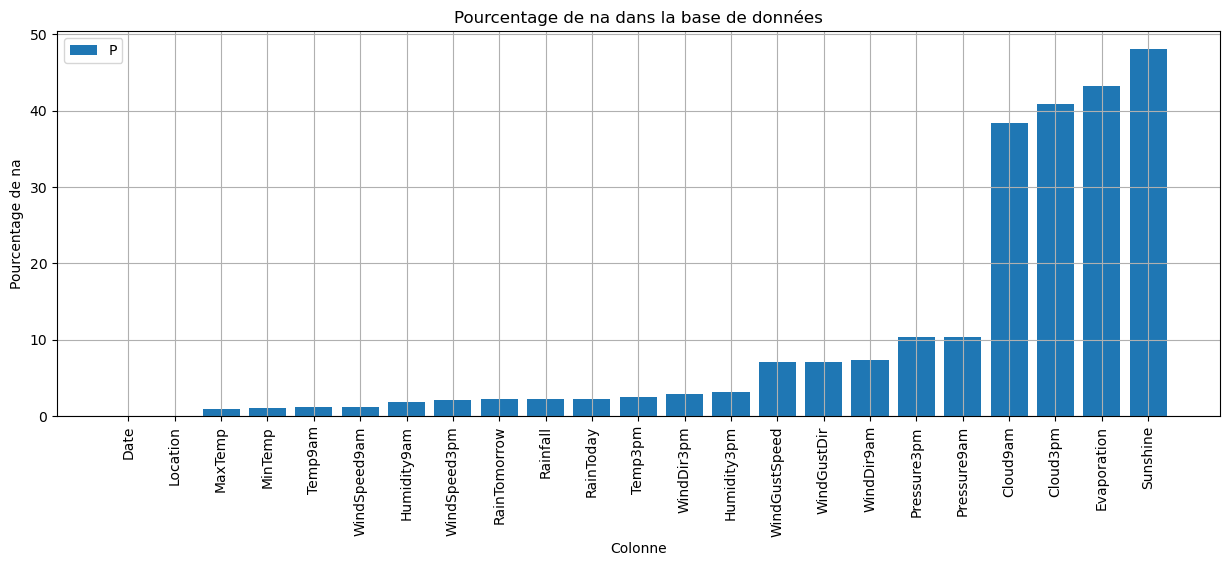

In [11]:
# calcul en pourcentage des valeurs manquantes pour chaque colonne du df pour modélisation dans un graphique
na_counts = round(df.isna().sum()/len(df)*100,1)

# Création d'un DataFrame à partir des résultats
emptiness = pd.DataFrame({'column_name': na_counts.index, 'percent_na': na_counts.values})
emptiness_sorted = emptiness.sort_values(by = "percent_na", ascending = True)

# Modélisation graphique des % de na
plt.figure(figsize=(15,5))
plt.grid()
plt.bar(x = emptiness_sorted.column_name, height = emptiness_sorted.percent_na)
plt.xlabel('Colonne')
plt.xticks(rotation=90)
plt.ylabel('Pourcentage de na')
plt.title('Pourcentage de na dans la base de données')
plt.legend('Pourcentage de na');

On constate que les colonnes Cloud3pm, Cloud9PM, Evaporation et Sunshine ont le plus fort taux de valeurs manquantes --> <p style="color: red;">il faudra décider comment gérer ces valeurs manquantes :  suppression des colonnes si estimées non nécessaires/exploitables ou compléter avec des valeurs par défaut basées sur les autres colonnes.</p>
Les autres colonnes sont à ~<10% de na.

Analyse de la répartition des valeurs : groupby localisation puis année +visualisation

In [12]:
display('Les années concernées par l étude sont:', np.sort(df['annee'].unique()))
display('Les localités concernées par l étude sont:', np.sort(df['Location'].unique()))

KeyError: 'annee'

<p style="color: red;"> Garde-t-on une différence de localité entre les villes et les aéroports associés à ces villes? --> 'Melbourne', 'MelbourneAirport', 'Perth', 'PerthAirport', 'Sydney', 'SydneyAirport'</p>

In [ ]:
# Réalisation d'un crosstab pour visualiser les relevés par années et localités
CT = pd.crosstab(df['Location'], df['annee'])
# Graphique en barres empilées
plt.figure(figsize=(15,15))
ct.plot(kind='bar', stacked=True, title="Nbr de relevés par année et localité", width = 0.5)
plt.ylabel("Nbr de relevés")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), borderaxespad=0.5);